# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [45]:
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt 
import math

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

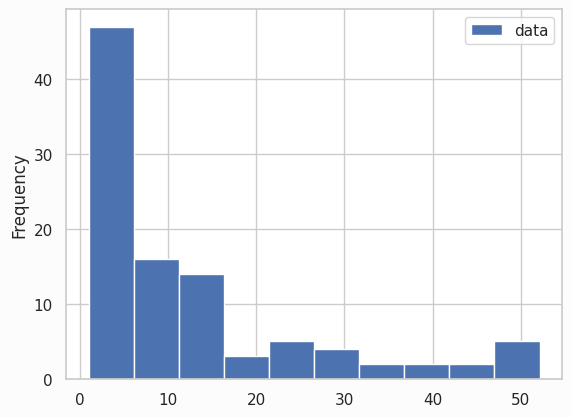

In [46]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

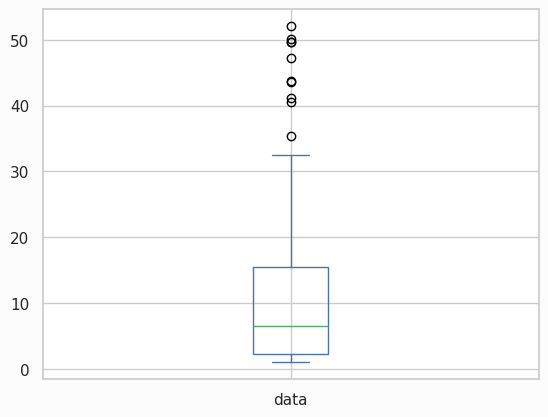

In [47]:
df.plot.box()

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [48]:
# LOADING THE DATASETS

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "DATA"

# Load only the Lending Club columns used later in the notebook so the full compressed file
# does not have to be held in memory.
accepted_required_columns = [
    "loan_amnt", "funded_amnt", "int_rate", "installment", "annual_inc", "dti",
    "fico_range_low", "fico_range_high", "delinq_2yrs", "inq_last_6mths",
    "open_acc", "pub_rec", "revol_bal", "revol_util", "total_acc", "mort_acc",
    "pub_rec_bankruptcies", "acc_now_delinq", "total_bal_ex_mort", "issue_d"
]

lending_club_dir = DATA_ROOT / "All Lending Club Loan Data"
Accepted_Lending_Club_Data = pd.read_csv(
    lending_club_dir / "accepted_2007_to_2018Q4.csv.gz",
    usecols=accepted_required_columns,
    encoding="latin1",
    low_memory=False
)
Rejected_Lending_Club_Data = pd.read_csv(
    lending_club_dir / "rejected_2007_to_2018Q4.csv.gz",
    nrows=1000,
    low_memory=False
)

home_credit_dir = DATA_ROOT / "home-credit-default-risk"
Home_Credit_app_TRAIN = pd.read_csv(home_credit_dir / "application_train.csv")

Loan_Default_Data = pd.read_csv(DATA_ROOT / "Loan_Default.csv")


## Accepted Lending Club Data 

In [49]:
Accepted_Lending_Club_Data.columns

histogram_columns = ["loan_amnt",              # Loan amount
    "funded_amnt",            # Amount funded
    "int_rate",               # Interest rate
    "installment",            # Monthly payment
    "annual_inc",             # Borrower income
    "dti",                    # Debt-to-income ratio
    "fico_range_low",         # Lower FICO score
    "open_acc",               # Open credit accounts
    "revol_bal",              # Revolving credit balance
    "revol_util",             # Revolving-credit utilization
    "total_acc",              # Total credit accounts
    "total_bal_ex_mort"       # Total balance excluding mortgages
]

In [50]:

# Histograms of Accepted Loan Data
def make_histograms(data, Title):
    columns_per_row = 3
    rows = math.ceil(len(data.columns) / columns_per_row)

    fig, axes = plt.subplots(
        rows,
        columns_per_row,
        figsize=(16, rows * 4)
    )

    axes = axes.flatten()

    for ax, column in zip(axes, data.columns):
        values = data[column].dropna()

        # Remove extreme values for clearer distributions
        values = values[values <= values.quantile(0.99)]

        ax.hist(values, bins=30, edgecolor="black")
        ax.set_title(f"Distribution of {column}")
        ax.set_xlabel(column)
        ax.set_ylabel("Frequency")
        ax.grid(axis="y", alpha=0.3)

        # descriptions = Accepted_Lending_Club_Data[column].describe().T
        # display(descriptions)


    # Hide any unused subplots
    for ax in axes[len(data.columns):]:
        ax.set_visible(False)

    fig.suptitle(f"{Title}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


def describe_distributions(data): 
    for col in data: 
        print(f'Distribution Summary for: {col}')
        print('Skewness', data[col].skew())
        print('Kurtosis', data[col].kurt())



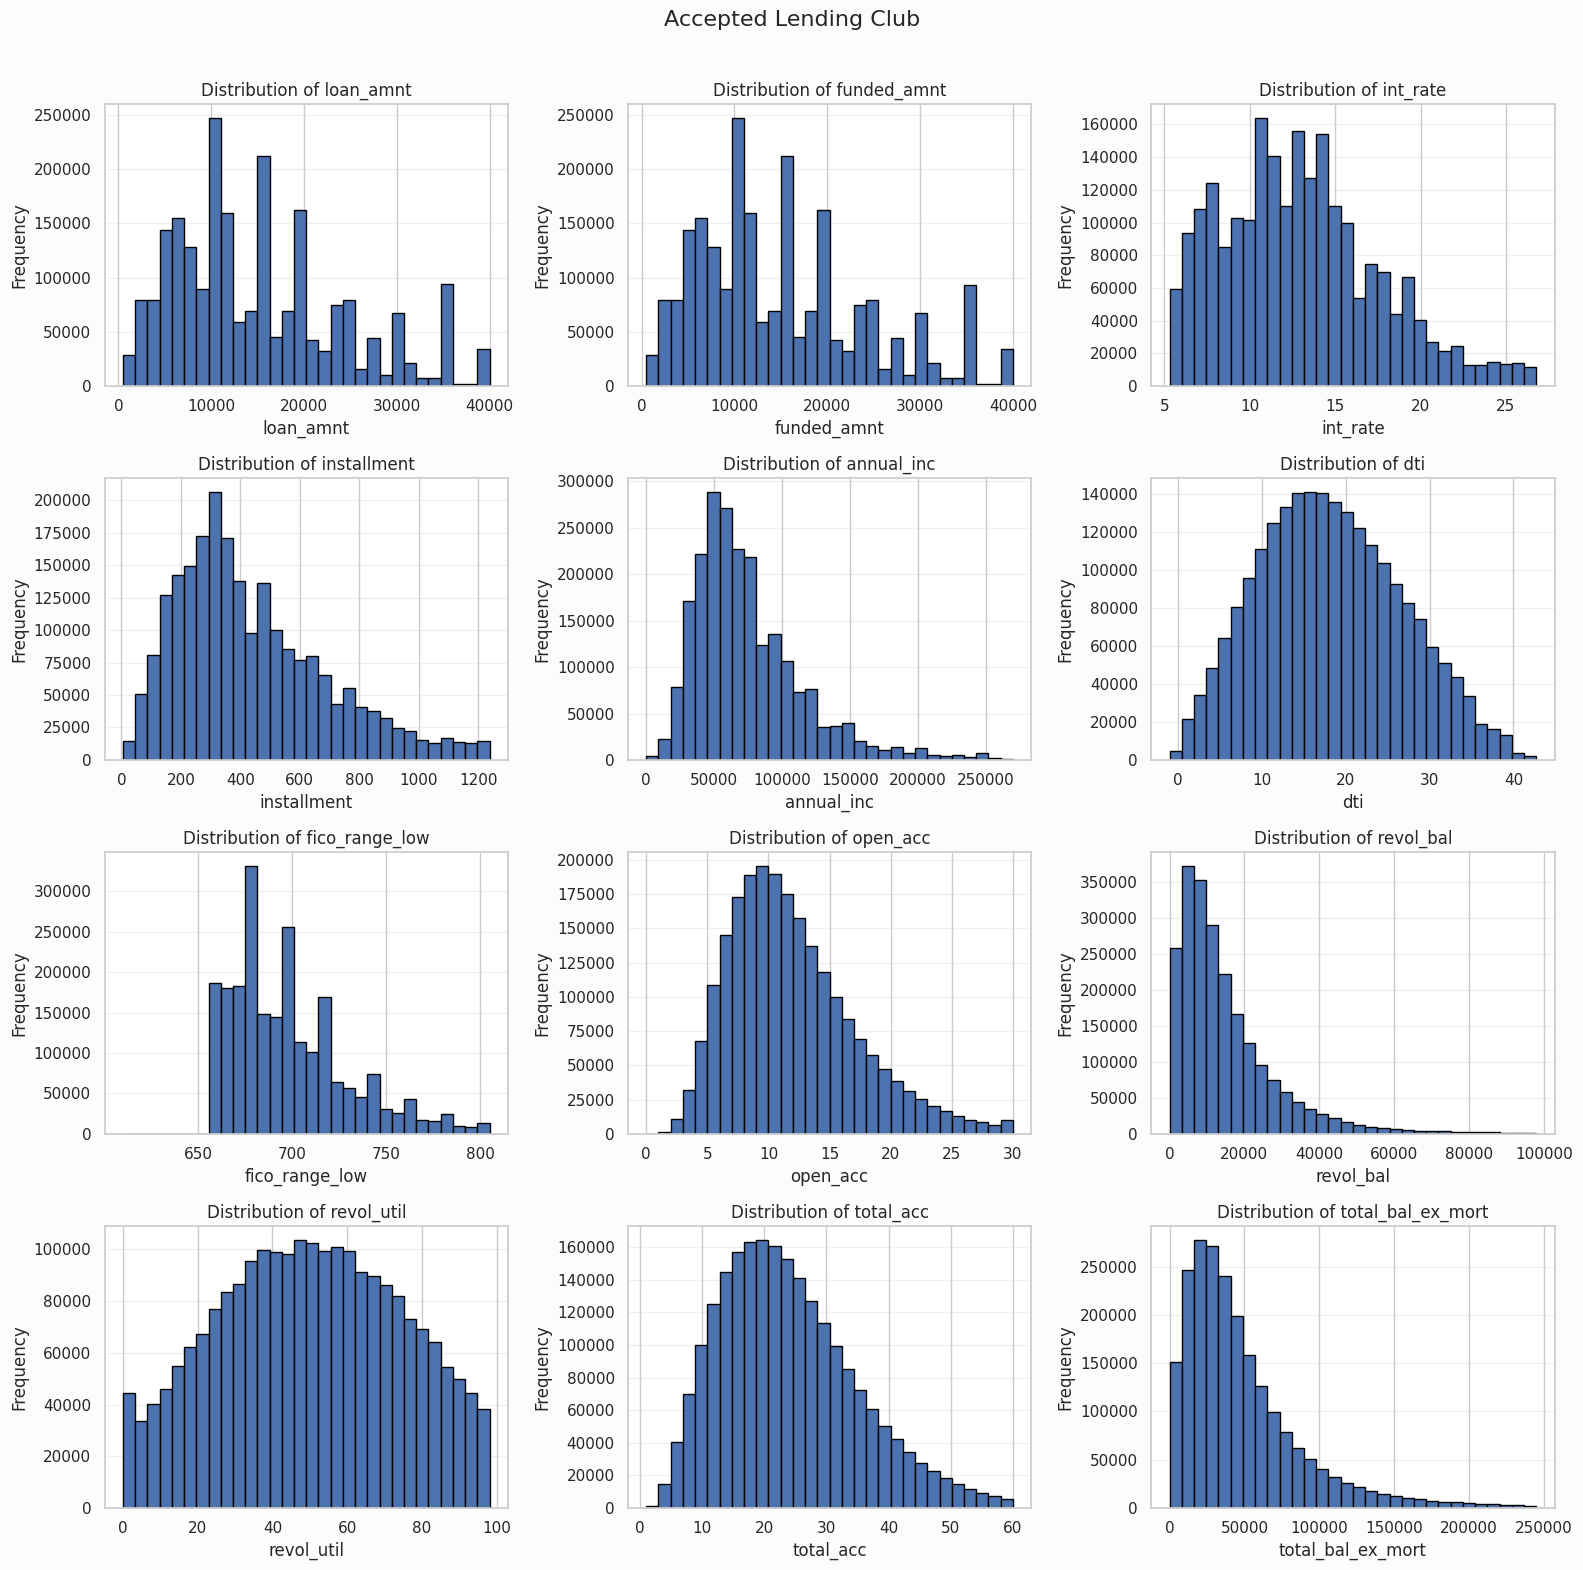

Distribution Summary for: loan_amnt
Skewness 0.777782328713943
Kurtosis -0.11943915766853852
Distribution Summary for: funded_amnt
Skewness 0.7787785935537788
Kurtosis -0.11700903869367485
Distribution Summary for: int_rate
Skewness 0.7680705624773504
Kurtosis 0.5940245696793398
Distribution Summary for: installment
Skewness 1.0017805692430077
Kurtosis 0.6898790425556007
Distribution Summary for: annual_inc
Skewness 493.8860883999474
Kurtosis 439001.65886074334
Distribution Summary for: dti
Skewness 29.20185446560357
Kurtosis 1755.2612777585414
Distribution Summary for: fico_range_low
Skewness 1.1928772060828803
Kurtosis 1.3151683691339144
Distribution Summary for: open_acc
Skewness 1.315544950640438
Kurtosis 3.4463767817959003
Distribution Summary for: revol_bal
Skewness 13.231988434981627
Kurtosis 643.1980553622421
Distribution Summary for: revol_util
Skewness 0.012555943084380352
Kurtosis -0.2226717499305506
Distribution Summary for: total_acc
Skewness 1.0074555008680115
Kurtosis 1.

In [51]:
make_histograms(Accepted_Lending_Club_Data[histogram_columns],'Accepted Lending Club')
describe_distributions(Accepted_Lending_Club_Data[histogram_columns])

In [52]:
# Descriptive Statistics of Each Histogram Column

descriptions = Accepted_Lending_Club_Data[histogram_columns].describe().T # the T is what makes the index the columns for a cleaner look
display(descriptions)



,count,mean,std,min,25%,50%,75%,max
loan_amnt,2260668.0,15046.931228,9190.245488,500.00,8000.00,12900.00,20000.00,4.000000e+04
funded_amnt,2260668.0,15041.664057,9188.413022,500.00,8000.00,12875.00,20000.00,4.000000e+04
int_rate,2260668.0,13.092829,4.832138,5.31,9.49,12.62,15.99,3.099000e+01
installment,2260668.0,445.806823,267.173535,4.93,251.65,377.99,593.32,1.719830e+03
annual_inc,2260664.0,77992.428687,112696.199574,0.00,46000.00,65000.00,93000.00,1.100000e+08
dti,2258957.0,18.824196,14.183329,-1.00,11.89,17.84,24.49,9.990000e+02
fico_range_low,2260668.0,698.588205,33.010376,610.00,675.00,690.00,715.00,8.450000e+02
open_acc,2260639.0,11.612402,5.640861,0.00,8.00,11.00,14.00,1.010000e+02
revol_bal,2260668.0,16658.458078,22948.305028,0.00,5950.00,11324.00,20246.00,2.904836e+06
revol_util,2258866.0,50.337696,24.713073,0.00,31.50,50.30,69.40,8.923000e+02


### Overall Distribution Shapes

| Feature(s) | Overall shape | Description |
|---|---|---|
| `loan_amnt`, `funded_amnt`, `int_rate` | Moderately right-skewed | Most observations are concentrated at lower-to-middle values, followed by a thinner tail of large loans or high interest rates. |
| `installment` | Right-skewed | Smaller monthly payments occur most frequently, with progressively fewer large payments. |
| `annual_inc`, `dti`, `revol_bal`, `total_bal_ex_mort` | Extremely right-skewed | These are strongly non-normal and contain long right tails caused by a small number of extremely large observations. |
| `fico_range_low`, `fico_range_high` | Unimodal and moderately right-skewed | Credit scores cluster within a common range but extend toward a smaller number of high scores. |
| `open_acc`, `total_acc`, `mort_acc` | Discrete and right-skewed | Lower account counts are most common, with fewer borrowers holding many accounts. |
| `delinq_2yrs`, `inq_last_6mths`, `pub_rec`, `pub_rec_bankruptcies`, `acc_now_delinq` | Zero-inflated and strongly right-skewed | Most borrowers have zero or very few negative credit events, while a small group has unusually high counts. |
| `revol_util` | Approximately symmetric and unimodal | This is the closest variable to a normal, bell-shaped distribution, although it is not perfectly normal. |

**Overall conclusion:** The Accepted Lending Club histograms are primarily **unimodal and right-skewed**, rather than normal, bimodal, or uniform. The strongest skew and most significant outliers occur in income, debt, balance, and negative-credit-event variables.

## Home Credit App Train Data 



In [53]:
home_credit_histogram_columns = [
    "AMT_INCOME_TOTAL",            # Applicant income
    "AMT_CREDIT",                  # Loan amount
    "AMT_ANNUITY",                 # Regular loan payment
    "AMT_GOODS_PRICE",             # Price of financed goods
    "OWN_CAR_AGE",                 # Age of applicant's car
    "EXT_SOURCE_1",                # External credit-risk score
    "EXT_SOURCE_2",                # External credit-risk score
    "EXT_SOURCE_3",                # External credit-risk score
    "REGION_POPULATION_RELATIVE"
]




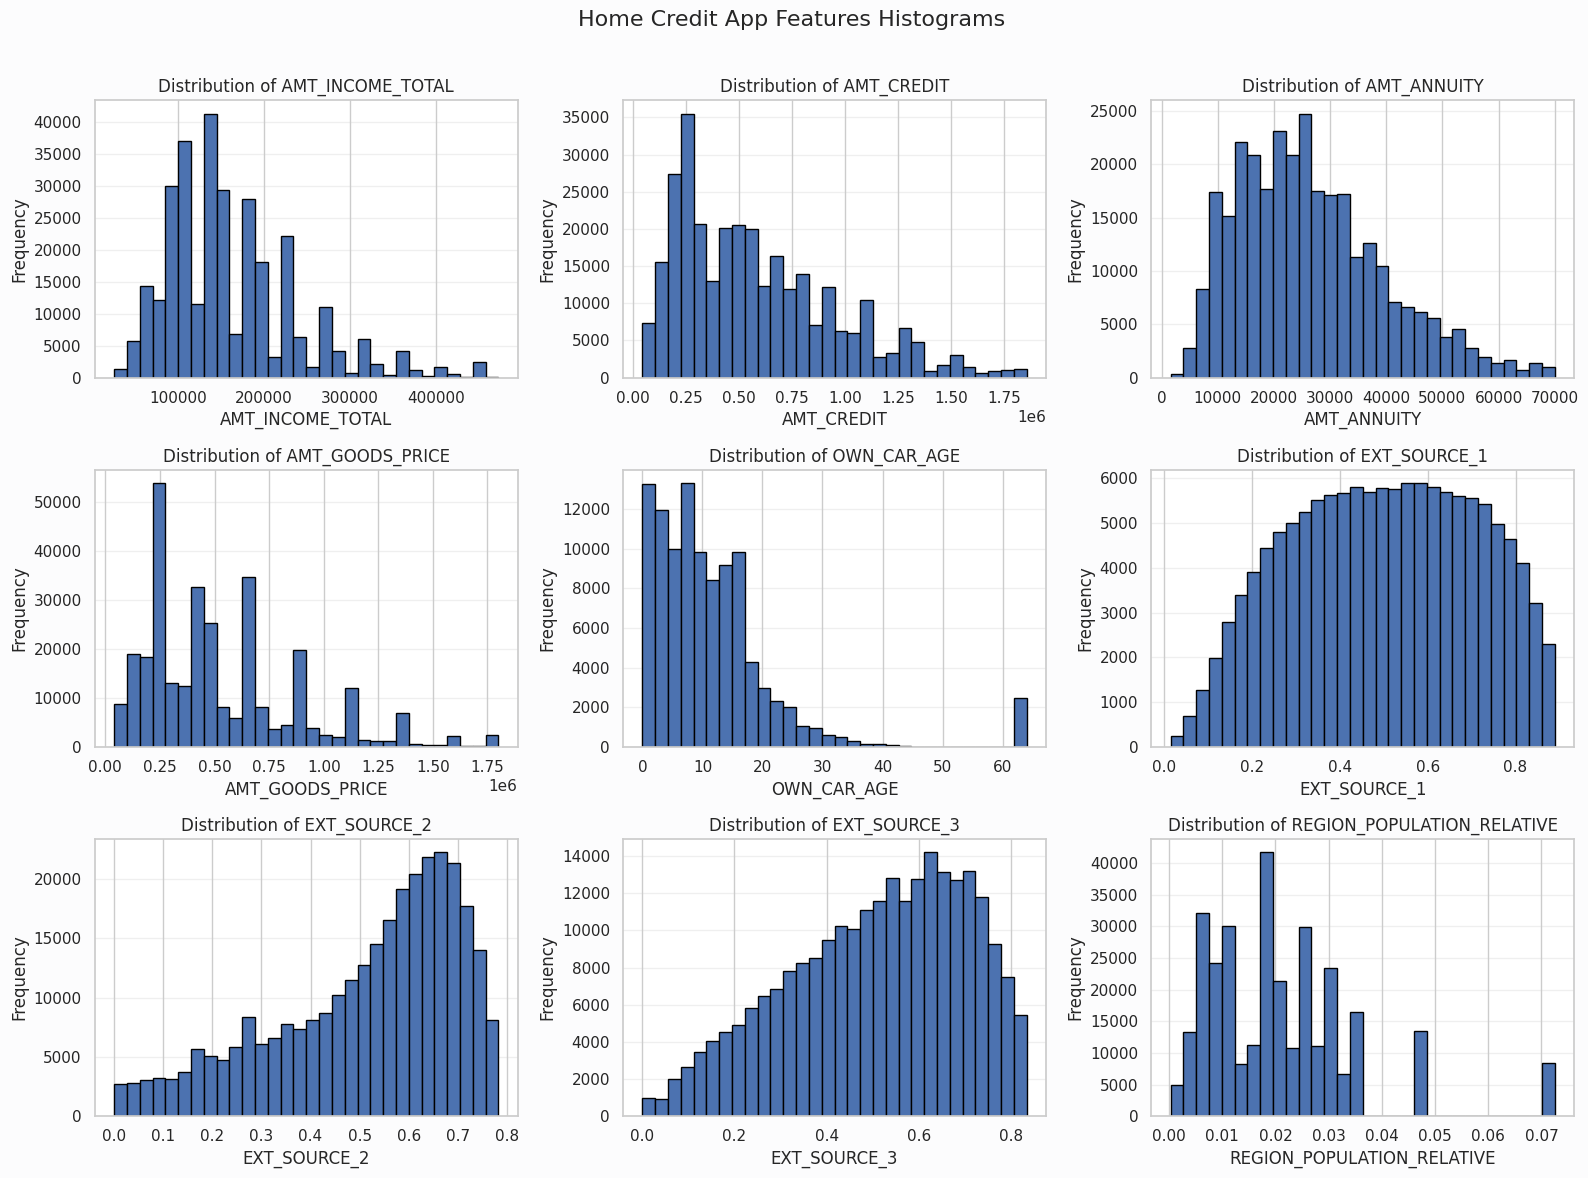

In [54]:
make_histograms(Home_Credit_app_TRAIN[home_credit_histogram_columns], 'Home Credit App Features Histograms')

In [55]:
# Descriptive Statistics 
Home_Credit_app_TRAIN[home_credit_histogram_columns].describe().T # the T is what makes the index the columns for a cleaner look

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
OWN_CAR_AGE,104582.0,12.061091,11.944812,0.000000e+00,5.000000,9.000000,15.000000,9.100000e+01
EXT_SOURCE_1,134133.0,0.502130,0.211062,1.456813e-02,0.334007,0.505998,0.675053,9.626928e-01
EXT_SOURCE_2,306851.0,0.514393,0.191060,8.173617e-08,0.392457,0.565961,0.663617,8.549997e-01
EXT_SOURCE_3,246546.0,0.510853,0.194844,5.272652e-04,0.370650,0.535276,0.669057,8.960095e-01
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,2.900000e-04,0.010006,0.018850,0.028663,7.250800e-02


### Home Credit Application Data Skew 

| Feature(s) | Overall shape | Description |
|---|---|---|
| `AMT_INCOME_TOTAL` | Extremely right-skewed | Most applicants have incomes within a common lower range, while a few unusually high incomes create a very long right tail. |
| `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE` | Unimodal and moderately right-skewed | Smaller loans, payments, and purchases are more common than very large amounts. |
| `DAYS_BIRTH` | Approximately symmetric and unimodal | Applicant ages are fairly balanced around the center and are closer to a normal distribution than most other features. |
| `DAYS_EMPLOYED` | Strongly right-skewed with an unusual secondary spike | The large positive coded value creates a separate concentration that can make the histogram appear bimodal. This special value should be cleaned before modeling. |
| `CNT_CHILDREN`, `CNT_FAM_MEMBERS`, `OWN_CAR_AGE` | Discrete and right-skewed | Small families and newer cars occur most often, followed by a long tail of larger counts or older cars. |
| `EXT_SOURCE_1` | Approximately symmetric and unimodal | Scores are relatively balanced around the center. |
| `EXT_SOURCE_2`, `EXT_SOURCE_3` | Moderately left-skewed | More applicants have middle-to-high external scores, with tails extending toward lower scores. |
| `REGION_POPULATION_RELATIVE`, `AMT_REQ_CREDIT_BUREAU_YEAR` | Right-skewed | Lower values occur most frequently, with fewer high values. |
| `OBS_30_CNT_SOCIAL_CIRCLE`, `DEF_30_CNT_SOCIAL_CIRCLE` | Zero-inflated and extremely right-skewed | Most values are zero or very small, while a few observations are unusually large. |

**Overall conclusion:** Most Home Credit histograms are **unimodal and right-skewed**, not normal or uniform. The external-source scores and age variable are more symmetric, while `DAYS_EMPLOYED` contains a special coded value that creates an artificial secondary peak.

### Univariate Plot: Home Credit Default Target

The univariate plot below shows the distribution of the `TARGET` column in `application_train.csv`. This is the most important single-variable check for the Home Credit Default Risk training data because it shows whether default cases are balanced against non-default cases.

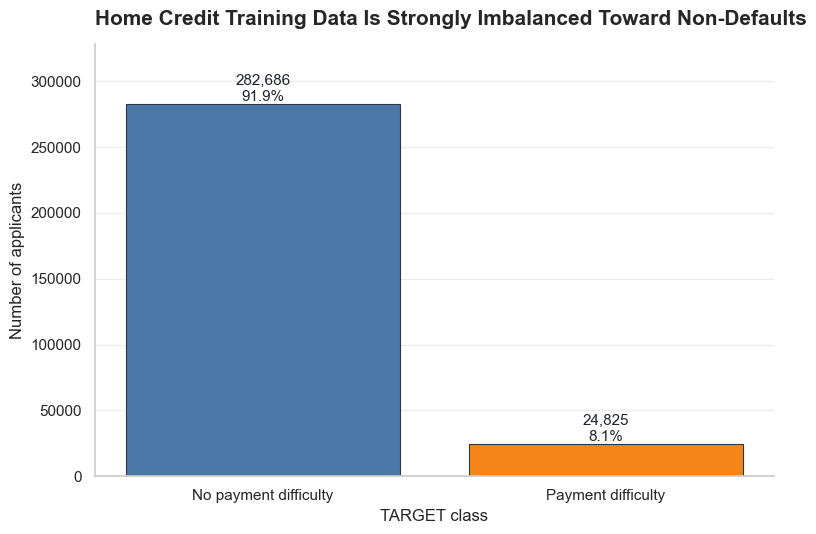

,TARGET,Applicant count,Percent of applicants,Default status
0,0,282686,91.927118,No payment difficulty
1,1,24825,8.072882,Payment difficulty


In [56]:
import seaborn as sns

# Univariate plot of the Home Credit Default Risk target variable
sns.set_theme(style="whitegrid")

target_summary = (
    Home_Credit_app_TRAIN["TARGET"]
    .value_counts()
    .sort_index()
    .rename_axis("TARGET")
    .reset_index(name="Applicant count")
)
target_summary["Percent of applicants"] = (
    target_summary["Applicant count"] / target_summary["Applicant count"].sum() * 100
)
target_summary["Default status"] = target_summary["TARGET"].map({
    0: "No payment difficulty",
    1: "Payment difficulty"
})

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(
    target_summary["Default status"],
    target_summary["Applicant count"],
    color=["#4C78A8", "#F58518"],
    edgecolor="#2F3640",
    linewidth=0.8
)

for bar, count, pct in zip(
    bars,
    target_summary["Applicant count"],
    target_summary["Percent of applicants"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color="#1F2430"
    )

ax.set_title(
    "Home Credit Training Data Is Strongly Imbalanced Toward Non-Defaults",
    fontsize=15,
    weight="bold",
    loc="left",
    pad=14
)
ax.set_xlabel("TARGET class")
ax.set_ylabel("Number of applicants")
ax.set_ylim(0, target_summary["Applicant count"].max() * 1.16)
ax.grid(axis="y", alpha=0.35)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

target_summary

**Conclusion:** The training data is highly imbalanced: 282,686 applicants, or 91.9%, have `TARGET = 0`, while 24,825 applicants, or 8.1%, have `TARGET = 1`. This means payment-difficulty cases are relatively rare, so any later model or evaluation should use metrics that handle class imbalance instead of relying only on accuracy.

### Storytelling With Data: univariate predictors of `TARGET`

The chart below compares several single-variable relationships with the target value. Each variable is split into five equal-size bands, then the plot shows the percentage of applicants in each band with `TARGET = 1` payment difficulty. This keeps the analysis univariate because each line studies one predictor at a time, while still making the variables easy to compare against the overall default rate.


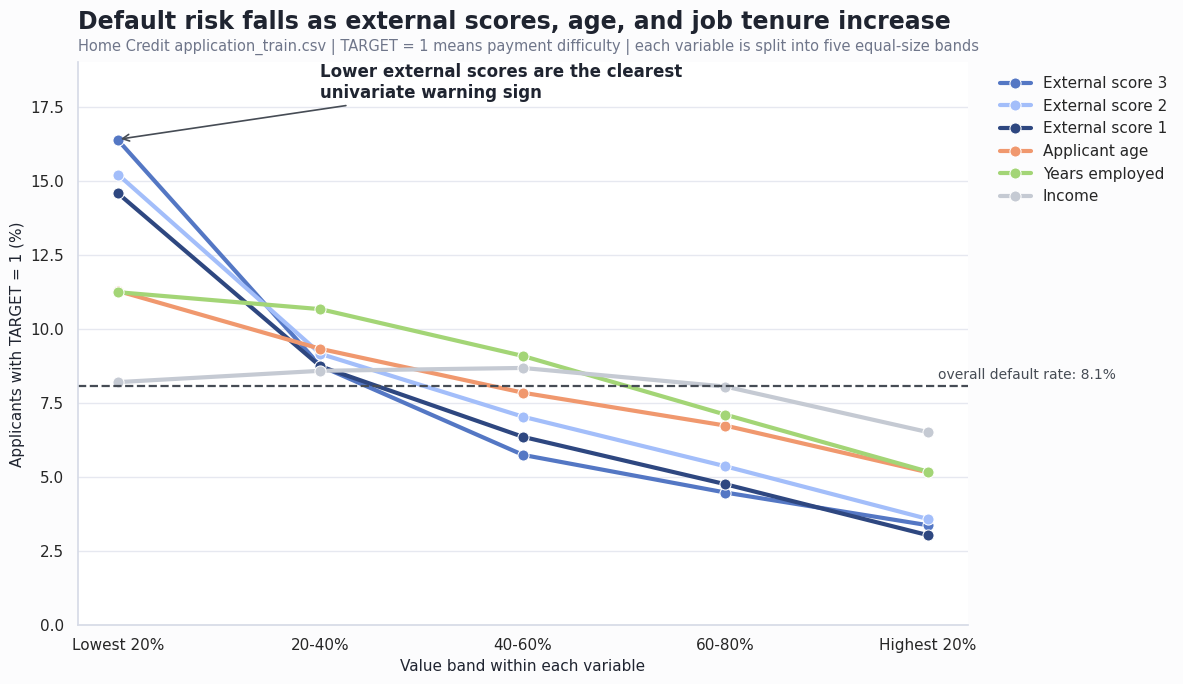

,Band,default_rate,applicants,Feature,Default rate (%)
0,Lowest 20%,0.163758,49445,External score 3,16.375771
1,20-40%,0.087505,49746,External score 3,8.750452
2,40-60%,0.057505,49578,External score 3,5.750535
3,60-80%,0.044795,49470,External score 3,4.479483
4,Highest 20%,0.033763,48307,External score 3,3.376322
5,Lowest 20%,0.152140,61371,External score 2,15.214026
6,20-40%,0.091607,61371,External score 2,9.160678
7,40-60%,0.070392,61371,External score 2,7.039155
8,60-80%,0.053652,61377,External score 2,5.365202
9,Highest 20%,0.035870,61361,External score 2,3.586969


In [57]:
import seaborn as sns

# Storytelling With Data style plot for univariate relationships with TARGET
risk_plot_df = Home_Credit_app_TRAIN[[
    "TARGET", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
    "DAYS_BIRTH", "DAYS_EMPLOYED", "AMT_INCOME_TOTAL"
]].copy()

# Convert coded day fields into easier-to-read units.
risk_plot_df["Age"] = -risk_plot_df["DAYS_BIRTH"] / 365.25
risk_plot_df["Years employed"] = np.where(
    risk_plot_df["DAYS_EMPLOYED"] < 0,
    -risk_plot_df["DAYS_EMPLOYED"] / 365.25,
    np.nan
)
risk_plot_df["Income"] = risk_plot_df["AMT_INCOME_TOTAL"]

features_to_plot = {
    "EXT_SOURCE_3": "External score 3",
    "EXT_SOURCE_2": "External score 2",
    "EXT_SOURCE_1": "External score 1",
    "Age": "Applicant age",
    "Years employed": "Years employed",
    "Income": "Income"
}

univariate_rows = []
for column, label in features_to_plot.items():
    analysis_frame = risk_plot_df[[column, "TARGET"]].dropna().copy()
    analysis_frame["Band"] = pd.qcut(
        analysis_frame[column],
        q=5,
        labels=["Lowest 20%", "20-40%", "40-60%", "60-80%", "Highest 20%"],
        duplicates="drop"
    )
    grouped = (
        analysis_frame.groupby("Band", observed=True)["TARGET"]
        .agg(default_rate="mean", applicants="size")
        .reset_index()
    )
    grouped["Feature"] = label
    grouped["Default rate (%)"] = grouped["default_rate"] * 100
    univariate_rows.append(grouped)

univariate_target_risk = pd.concat(univariate_rows, ignore_index=True)
overall_default_rate = Home_Credit_app_TRAIN["TARGET"].mean() * 100

sns.set_theme(style="whitegrid")
plt.rcParams["figure.facecolor"] = "#FCFCFD"
plt.rcParams["axes.facecolor"] = "#FFFFFF"
plt.rcParams["font.family"] = "DejaVu Sans"

palette = {
    "External score 3": "#5477C4",
    "External score 2": "#A3BEFA",
    "External score 1": "#2E4780",
    "Applicant age": "#F0986E",
    "Years employed": "#A3D576",
    "Income": "#C5CAD3"
}

fig, ax = plt.subplots(figsize=(12, 7))

sns.lineplot(
    data=univariate_target_risk,
    x="Band",
    y="Default rate (%)",
    hue="Feature",
    marker="o",
    linewidth=3,
    markersize=8,
    palette=palette,
    ax=ax
)

# Overall rate gives the reader an immediate benchmark.
ax.axhline(
    overall_default_rate,
    color="#464C55",
    linestyle="--",
    linewidth=1.6
)
ax.text(
    4.05,
    overall_default_rate + 0.15,
    f"overall default rate: {overall_default_rate:.1f}%",
    color="#464C55",
    fontsize=10,
    va="bottom"
)

ax.annotate(
    "Lower external scores are the clearest\nunivariate warning sign",
    xy=(0, 16.4),
    xytext=(1.0, 17.8),
    arrowprops=dict(arrowstyle="->", color="#464C55", linewidth=1.2),
    color="#1F2430",
    fontsize=12,
    weight="bold"
)

ax.set_title(
    "Default risk falls as external scores, age, and job tenure increase",
    fontsize=17,
    weight="bold",
    color="#1F2430",
    loc="left",
    pad=24
)
ax.text(
    0,
    1.02,
    "Home Credit application_train.csv | TARGET = 1 means payment difficulty | each variable is split into five equal-size bands",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#6F768A"
)

ax.set_xlabel("Value band within each variable", fontsize=11, color="#1F2430")
ax.set_ylabel("Applicants with TARGET = 1 (%)", fontsize=11, color="#1F2430")
ax.set_ylim(0, 19)
ax.grid(axis="y", color="#E6E8F0")
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D7DBE7")
ax.spines["bottom"].set_color("#D7DBE7")
ax.legend(title="", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

univariate_target_risk

## Loan Default Dataset 

In [58]:
Loan_Default_Histogram_Columns = [
    "loan_amount",             # Requested loan amount
    "rate_of_interest",        # Loan interest rate
    "Interest_rate_spread",    # Interest-rate spread
    "Upfront_charges",         # Initial loan charges
    "property_value",          # Property value
    "income",                  # Applicant income
    "Credit_Score",            # Applicant credit score
    "LTV",                     # Loan-to-value ratio
    "dtir1"                    # Debt-to-income ratio
]



Loan_Default_Data.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='str')

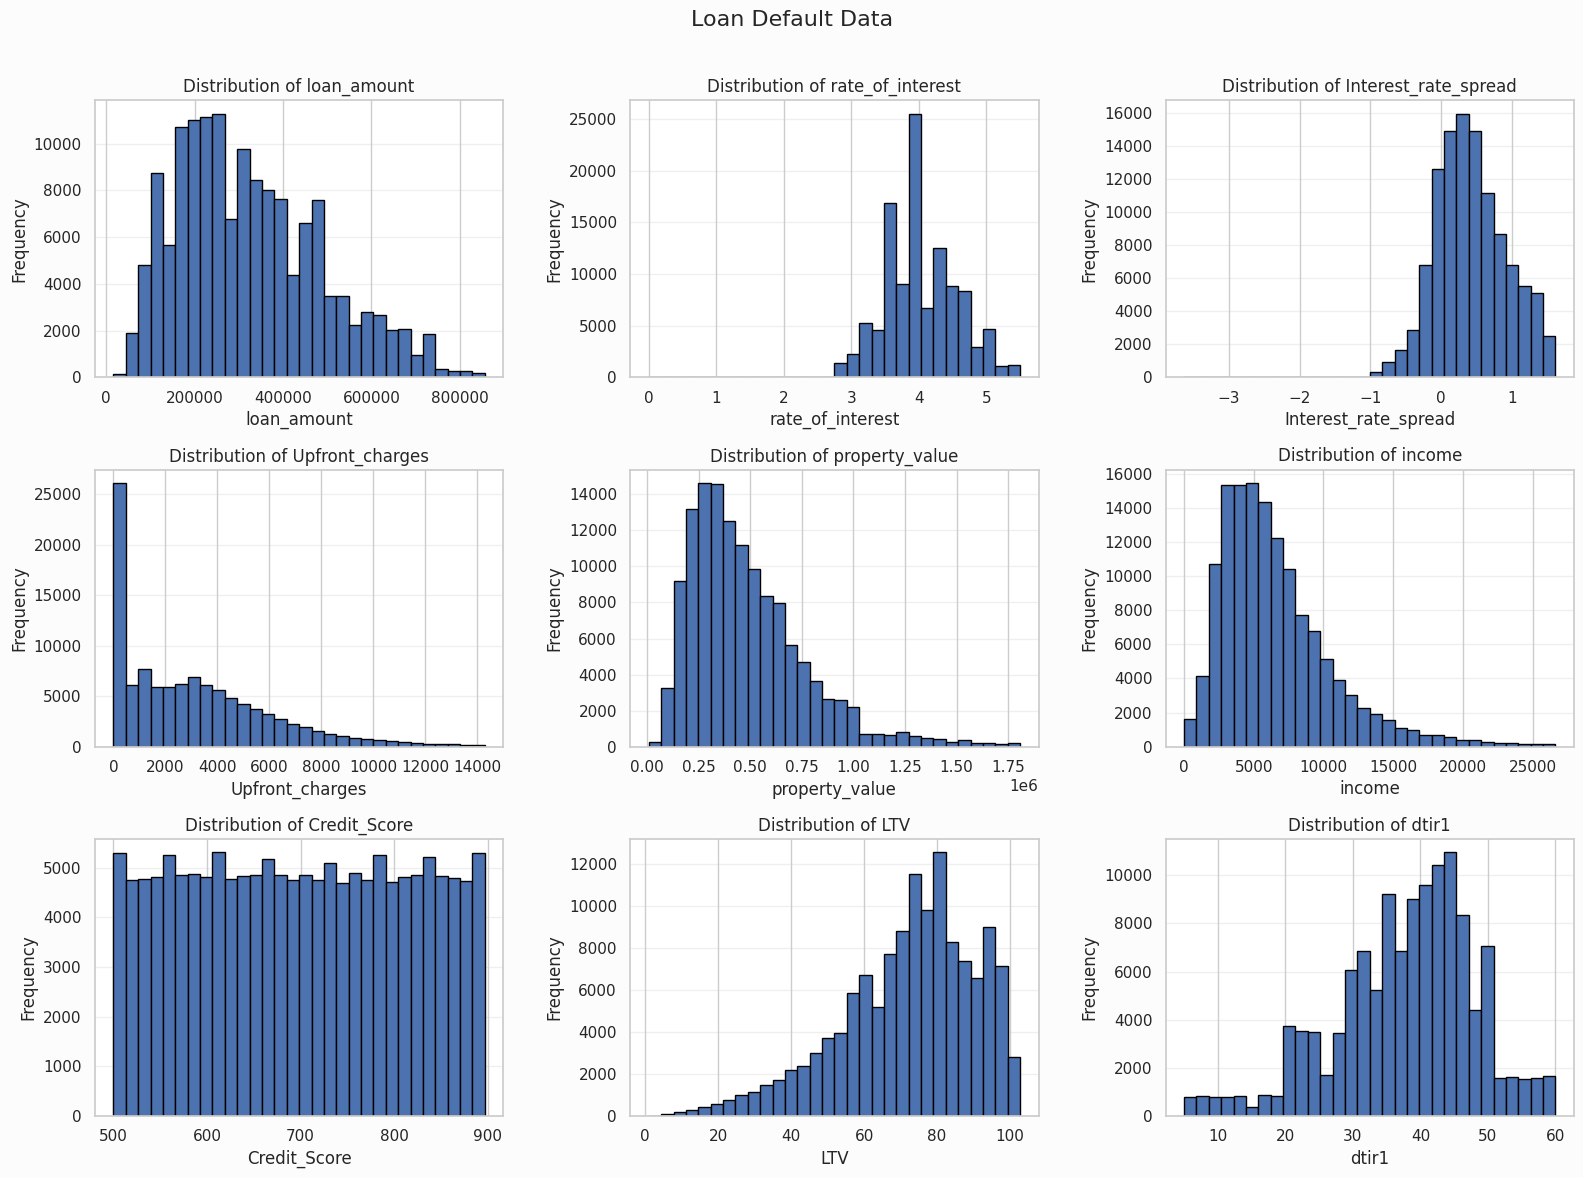

In [59]:
make_histograms(Loan_Default_Data[Loan_Default_Histogram_Columns], 'Loan Default Data')

### Overall Distribution Shapes

| Feature(s) | Overall shape | Description |
|---|---|---|
| `loan_amount`, `Upfront_charges` | Unimodal and right-skewed | Smaller loans and upfront charges occur most frequently, with fewer observations at very large values. |
| `property_value`, `income` | Extremely right-skewed | These variables are strongly non-normal and have long upper tails caused by a small number of unusually large values. |
| `rate_of_interest`, `Interest_rate_spread` | Approximately symmetric to mildly right-skewed | Values cluster around a central range and are closer to normal than the monetary variables. |
| `term` | Discrete and strongly left-skewed | Most loans use the longest common term, with fewer loans using shorter terms. |
| `Credit_Score` | Approximately uniform and symmetric | Scores are spread relatively evenly across the available range rather than forming a clear bell-shaped peak. |
| `dtir1` | Moderately left-skewed | Values are concentrated toward the higher end, with a tail extending toward lower debt-to-income ratios. |
| `LTV` | Extremely right-skewed | Most loan-to-value ratios fall within a common range, but a few extreme values create a very long right tail and may represent data-quality issues. |
| `Status` | Binary and imbalanced | This is not a continuous distribution. It has two bars, with approximately 75% status `0` and 25% status `1`. |

**Overall conclusion:** The Loan Default histograms include a mixture of **right-skewed, left-skewed, uniform, discrete, and binary distributions**. Most monetary variables are right-skewed, while `Credit_Score` is approximately uniform and `Status` is an imbalanced binary distribution.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

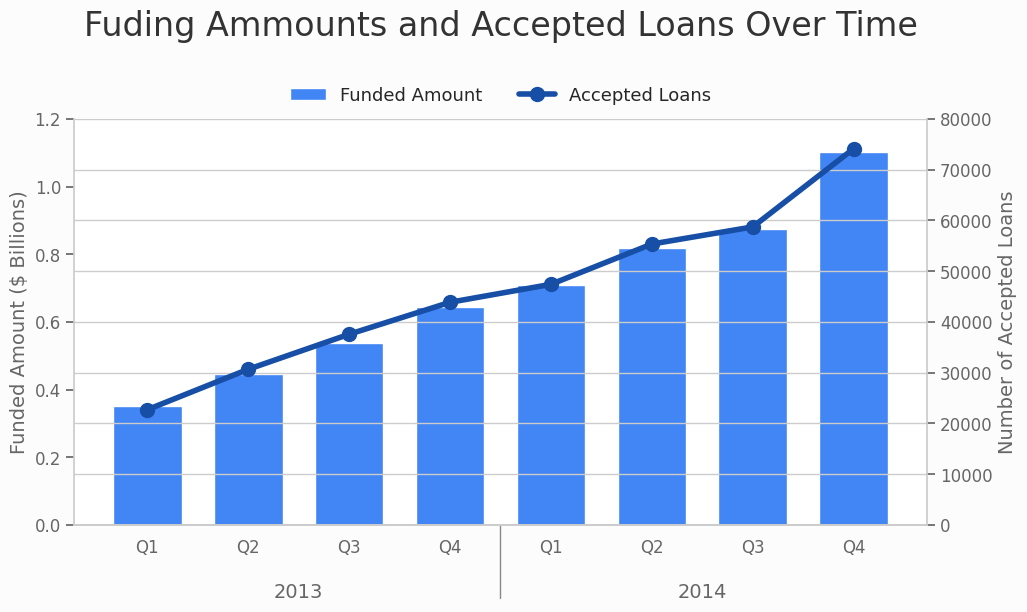

In [60]:
# Reproduction of Figure 2.26: Secondary y-axis
# Bars show quarterly funded loan volume; the line shows accepted loan count.

figure_226_data = Accepted_Lending_Club_Data[["issue_d", "funded_amnt"]].copy()
figure_226_data["issue_d"] = pd.to_datetime(
    figure_226_data["issue_d"], format="%b-%Y", errors="coerce"
)
figure_226_data = figure_226_data[
    figure_226_data["issue_d"].dt.year.isin([2013, 2014])
].copy()
figure_226_data["quarter"] = figure_226_data["issue_d"].dt.to_period("Q")

quarterly_lending = (
    figure_226_data.groupby("quarter")
    .agg(
        funded_billions=("funded_amnt", lambda values: values.sum() / 1_000_000_000),
        accepted_loans=("funded_amnt", "size"),
    )
    .reset_index()
)

x = np.arange(len(quarterly_lending))
quarter_labels = [f"Q{quarter.quarter}" for quarter in quarterly_lending["quarter"]]

fig, ax_left = plt.subplots(figsize=(11, 7))
ax_right = ax_left.twinx()

bars = ax_left.bar(
    x,
    quarterly_lending["funded_billions"],
    width=0.68,
    color="#4285F4",
    label="Funded Amount",
)
line, = ax_right.plot(
    x,
    quarterly_lending["accepted_loans"],
    color="#174EA6",
    linewidth=4,
    marker="o",
    markersize=10,
    label="Accepted Loans",
)

ax_left.set_title("Fuding Ammounts and Accepted Loans Over Time", loc="center", fontsize=24, color="#333333", pad=60)
ax_left.set_ylabel("Funded Amount ($ Billions)", fontsize=14, color="#666666")
ax_right.set_ylabel("Number of Accepted Loans", fontsize=14, color="#666666")
ax_left.set_xticks(x, quarter_labels)
ax_left.set_ylim(0, 1.2)
ax_right.set_ylim(0, 80_000)

ax_left.legend(
    [bars, line],
    ["Funded Amount", "Accepted Loans"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    frameon=False,
    ncol=2,
    fontsize=13,
)

ax_left.text(1.5, -0.18, "2013", transform=ax_left.get_xaxis_transform(), ha="center", fontsize=14, color="#666666")
ax_left.text(5.5, -0.18, "2014", transform=ax_left.get_xaxis_transform(), ha="center", fontsize=14, color="#666666")
ax_left.axvline(3.5, ymin=-0.18, ymax=0, color="#888888", linewidth=1, clip_on=False)

for axis in (ax_left, ax_right):
    axis.tick_params(colors="#666666", labelsize=12)
    axis.spines["top"].set_visible(False)
ax_left.spines["right"].set_visible(False)
ax_right.spines["left"].set_visible(False)
ax_left.grid(False)

plt.subplots_adjust(bottom=0.20, top=0.78)
plt.show()
